# 7. Neuronales Netz für Regression

**KI1-Projekt 308** — California Housing Datensatz

**Schwerpunkt P5 (Kernaufgabe):** Neuronales Netz mit TensorFlow/Keras
für die Vorhersage von Hauspreisen. Vergleich mit linearer Regression.

Vorlage: Blatt 12 (TensorFlow Regression), Kapitel 8 Folien

> ⚠️ **Python-Version:** Dieses Notebook benötigt **Python 3.13**. für intel Mac 3.11.14  
> TensorFlow (≥ 2.18) ist **nicht** kompatibel mit Python 3.14+.  
> Venv erstellen mit: `python3.13 -m venv .venv`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.linear_model import LinearRegression

from utils.data import load_and_clean_data, get_train_test_split
from utils.evaluation import evaluate_predictions, add_result
from utils.plotting import plot_predicted_vs_actual, plot_residuals, save_fig

plt.rcParams['figure.dpi'] = 100
%matplotlib inline

print(f"TensorFlow Version: {tf.__version__}")

2026-03-14 16:00:50.760132: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow Version: 2.16.2


## 7.1 Daten laden (skaliert)

Neuronale Netze benötigen skalierte Eingabedaten für effizientes Training.

In [2]:
df = load_and_clean_data()
X_train, X_test, y_train, y_test, scaler, feature_names = get_train_test_split(df, scaler='standard')

# Validierungssplit aus Trainingsdaten
val_split = int(0.8 * len(X_train))
X_val, y_val = X_train[val_split:], y_train[val_split:]
X_train_nn, y_train_nn = X_train[:val_split], y_train[:val_split]

print(f"Training:   {X_train_nn.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")
print(f"Features:   {feature_names}")

Training:   (11126, 8)
Validation: (2782, 8)
Test:       (3478, 8)
Features:   ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Test von NN Plain mit [64, 32] NN L2 mit [128, 64, 32] NN L1 + L2 mit [128, 64, 32] NN L2 + Dropout mit [128, 64, 32]

                        Modell  Test_MSE  Test_MAE Parameter Epochen_bis_Stop
NN_L3                    NN_L3  0.211567  0.322238     11521               50
NN_plain_klein  NN_plain_klein  0.217474  0.329136      2689               52
NN_L2                    NN_L2  0.232094  0.309287     11521               89
NN_L1_L2              NN_L1_L2  0.262337  0.332263     11521              137
NN_L1                    NN_L1  0.286491   0.34665     11521               76


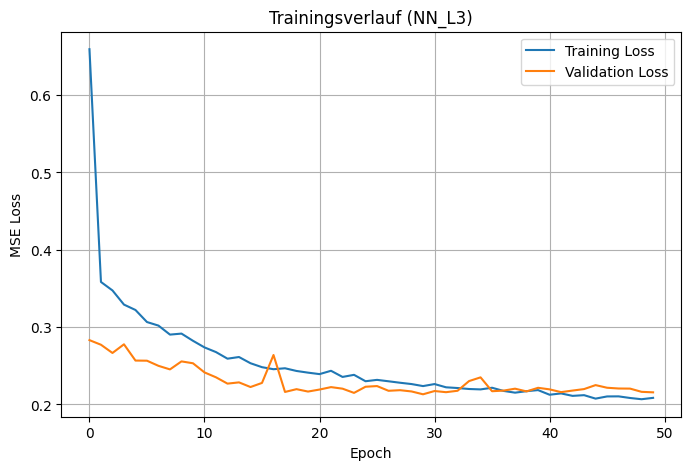

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import matplotlib.pyplot as plt


# Optional: eigener L3 Regularizer


class L3Regularizer(keras.regularizers.Regularizer):
    
    def __init__(self, l3=0.0001):
        self.l3 = l3

    def __call__(self, x):
        return self.l3 * tf.reduce_sum(tf.abs(x) ** 3)

    def get_config(self):
        return {"l3": self.l3}



# Modellfunktion


def build_model_regularized(
        input_dim,
        hidden_layers,
        activation="relu",
        learning_rate=0.001,
        regularizer=None,
        dropout_rate=0.0
    ):

    model = keras.Sequential()

    model.add(layers.Input(shape=(input_dim,)))

    for units in hidden_layers:

        model.add(
            layers.Dense(
                units,
                activation=activation,
                kernel_regularizer=regularizer
            )
        )

        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )

    return model



# Trainingsfunktion


def train_and_evaluate(
        model,
        model_name,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=300,
        batch_size=32
    ):

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stopping]
    )

    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

    result = {
        "Modell": model_name,
        "Test_MSE": test_loss,
        "Test_MAE": test_mae,
        "Parameter": model.count_params(),
        "Epochen_bis_Stop": len(history.history["loss"])
    }

    return history, result



# Modelle definieren


model_configs = {

    "NN_plain_klein": {
        "hidden_layers": [64, 32],
        "regularizer": None,
        "dropout_rate": 0.0
    },

    "NN_L1": {
        "hidden_layers": [128, 64, 32],
        "regularizer": keras.regularizers.l1(0.001),
        "dropout_rate": 0.1
    },

    "NN_L2": {
        "hidden_layers": [128, 64, 32],
        "regularizer": keras.regularizers.l2(0.001),
        "dropout_rate": 0.1
    },

    "NN_L1_L2": {
        "hidden_layers": [128, 64, 32],
        "regularizer": keras.regularizers.l1_l2(l1=0.0005, l2=0.0005),
        "dropout_rate": 0.1
    },
    "NN_L3": {
        "hidden_layers": [128, 64, 32],
        "regularizer": L3Regularizer(0.0001),
        "dropout_rate": 0.1
    }   
}



# Modelle trainieren


results = {}
histories = {}
trained_models = {}

for model_name, config in model_configs.items():

    model = build_model_regularized(
        input_dim=X_train.shape[1],
        hidden_layers=config["hidden_layers"],
        activation="relu",
        learning_rate=0.001,
        regularizer=config["regularizer"],
        dropout_rate=config["dropout_rate"]
    )

    history, result = train_and_evaluate(
        model=model,
        model_name=model_name,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        epochs=300,
        batch_size=32
    )

    # Ergebnisse speichern
    results[model_name] = result
    histories[model_name] = history
    trained_models[model_name] = model
    

# Ergebnisse anzeigen


results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test_MSE")

print(results_df)



# Trainingsplot


best_model_name = results_df.index[0]
best_history = histories[best_model_name]

plt.figure(figsize=(8,5))

plt.plot(best_history.history["loss"], label="Training Loss")
plt.plot(best_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"Trainingsverlauf ({best_model_name})")

plt.legend()
plt.grid(True)
plt.show()

## 7.2 Referenz: Lineare Regression

Aufgabenstellung fordert explizit den Vergleich mit linearer Regression.

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Modell erstellen
lr = LinearRegression()

# trainieren
lr.fit(X_train, y_train)

# Vorhersage
y_pred = lr.predict(X_test)

# Fehler berechnen
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression Ergebnisse")
print("---------------------------")
print("Test MSE:", mse)
print("Test MAE:", mae)

Linear Regression Ergebnisse
---------------------------
Test MSE: 0.3339224280070957
Test MAE: 0.43412545741114333


## 7.3 Basismodell: Einfaches neuronales Netz

Als Ausgangspunkt wird zunächst ein einfaches neuronales Netz mit einer Hidden-Layer
und 32 Neuronen trainiert. Dieses Modell dient als Referenzmodell, bevor im weiteren
Verlauf tiefere und breitere Architekturen sowie verschiedene Regularisierungsmethoden
untersucht werden.

In [5]:
# 7.3 Basismodell: Einfaches neuronales Netz


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd


# Eigene Modellfunktion nur für Abschnitt 7.3


def build_model_baseline(hidden_layers, activation="relu", learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )

    return model


# Eigene Trainings- und Auswertungsfunktion nur für 7.3

def train_and_evaluate_baseline(
    model,
    model_name,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=300,
    batch_size=32
):
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stopping]
    )

    y_pred_train = model.predict(X_train, verbose=0).flatten()
    y_pred_test = model.predict(X_test, verbose=0).flatten()

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    result = {
        "Modell": model_name,
        "Train_MSE": mean_squared_error(y_train, y_pred_train),
        "Test_MSE": mean_squared_error(y_test, y_pred_test),
        "Train_MAE": mean_absolute_error(y_train, y_pred_train),
        "Test_MAE": mean_absolute_error(y_test, y_pred_test),
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "Overfit_Gap": train_r2 - test_r2,
        "Parameter": model.count_params(),
        "Epochen_bis_Stop": len(history.history["loss"])
    }

    return history, result


# Basismodell trainieren


model_1 = build_model_baseline(
    hidden_layers=[32],
    activation="relu",
    learning_rate=0.001
)

model_1.summary()

history_1, result_1 = train_and_evaluate_baseline(
    model=model_1,
    model_name="NN [32] ReLU",
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    epochs=300,
    batch_size=32
)

baseline_results_df = pd.DataFrame([result_1])
baseline_results_df

print("Basismodell erfolgreich trainiert.")
print(f"Test_MSE: {result_1['Test_MSE']:.4f}")
print(f"Test_MAE: {result_1['Test_MAE']:.4f}")
print(f"Test_R2: {result_1['Test_R2']:.4f}")
print(f"Overfit_Gap: {result_1['Overfit_Gap']:.4f}")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

Basismodell erfolgreich trainiert.
Test_MSE: 0.2251
Test_MAE: 0.3359
Test_R2: 0.7523
Overfit_Gap: 0.0156


### Kurzinterpretation des Basismodells

Das Basismodell mit einer Hidden-Layer und 32 Neuronen liefert bereits brauchbare
Ergebnisse. Die Trainings- und Testfehler liegen nah beieinander, ebenso unterscheiden
sich die R²-Werte nur gering. Der kleine Overfit-Gap zeigt, dass das Modell keine
starke Überanpassung aufweist und somit als stabile Ausgangsbasis für die weiteren
Experimente geeignet ist.

Trotz dieser soliden Basis ist zu erwarten, dass eine Variation der Hidden-Layer-
Struktur und der Einsatz von Regularisierungsmethoden die Modellgüte weiter
verbessern können. Aus diesem Grund werden im weiteren Verlauf komplexere
Architekturen sowie L1-, L2-, L1+L2- und L3-Regularisierung untersucht.

In [6]:
model_1 = build_model_baseline([32], activation='relu', learning_rate=0.001)
model_1.summary()

history_1, result_1 = train_and_evaluate_baseline(
    model_1,
    "NN [32] ReLU",
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=300
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print("Tatsächliche Epochen:", len(history_1.history["loss"])) #sofern die epochen nicht dem maximalen Wert entsprechen wurde overfitting verhidnert 

Tatsächliche Epochen: 168


### 7.3.1 Vergleich mit und ohne L2-Regularisierung (Voruntersuchung)

In diesem Abschnitt wurden zunächst einfache Experimente durchgeführt, um den
Einfluss von L2-Regularisierung auf ein neuronales Netz zu untersuchen.
Dabei wurde ein Basismodell ohne Regularisierung mit einem Modell mit
L2-Regularisierung verglichen.

Diese Untersuchung diente als erste Orientierung bezüglich Overfitting und
Modellkomplexität. Die finale systematische Analyse verschiedener
Regularisierungsmethoden (L1, L2, L1+L2 und L3) erfolgt später im gemeinsamen
Modellvergleich.

def build_model_plain(hidden_layers, activation='relu', learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model


def build_model_l2(hidden_layers, activation='relu', learning_rate=0.001, l2_value=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(
            layers.Dense(
                units,
                activation=activation,
                kernel_regularizer=keras.regularizers.l2(l2_value)
            )
        )
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

Modelle Trainieren

#### Plain Modell
model_plain = build_model_plain([64, 32])
history_plain, result_plain = train_and_evaluate(
    model_plain,
    "NN Plain",
    epochs=300
)

#### L2 Modell
model_l2 = build_model_l2([64, 32])
history_l2, result_l2 = train_and_evaluate(
    model_l2,
    "NN L2",
    epochs=300
)

Parameterzahl vergleichen

print("Plain Parameter:", model_plain.count_params())
print("L2 Parameter:", model_l2.count_params())

Tatsächliche Epochen vergleichen

print("Plain Epochen:", len(history_plain.history["loss"]))
print("L2 Epochen:", len(history_l2.history["loss"]))

Overfitting differnez berechnen 

def overfit_gap(result):
    return result["R² Train"] - result["R² Test"]

print("Plain Overfit Gap:", overfit_gap(result_plain))
print("L2 Overfit Gap:", overfit_gap(result_l2))

Lernkurven vergleichen

plt.figure(figsize=(10,5))

plt.plot(history_plain.history["val_loss"], label="Plain Val Loss")
plt.plot(history_l2.history["val_loss"], label="L2 Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

Residuenvergleich 

y_test_pred_plain = model_plain.predict(X_test).flatten()
y_test_pred_l2 = model_l2.predict(X_test).flatten()

res_plain = y_test - y_test_pred_plain
res_l2 = y_test - y_test_pred_l2

plt.figure(figsize=(10,5))
plt.scatter(y_test_pred_plain, res_plain, alpha=0.4, label="Plain")
plt.scatter(y_test_pred_l2, res_l2, alpha=0.4, label="L2")
plt.axhline(0)
plt.legend()
plt.title("Residual Comparison")
plt.show()

#### Vergleich der Modelle mit und ohne L2-Regularisierung:

Das neuronale Netz ohne Regularisierung (Plain) erreicht einen Test-R² von 0.7637 bei einem Overfitting-Gap von ca. 0.040. Das Modell mit L2-Regularisierung erzielt hingegen einen leicht höheren Test-R² von 0.7715 und weist mit ca. 0.024 einen deutlich geringeren Overfitting-Gap auf.

Die L2-Regularisierung reduziert somit die Differenz zwischen Trainings- und Testleistung und verbessert gleichzeitig die Generalisierungsfähigkeit des Modells. Auch die Validierungskurve verläuft stabiler und zeigt weniger Schwankungen als beim unregularisierten Modell.

Die Residuenverteilung beider Modelle ist insgesamt ähnlich, jedoch wirkt das L2-Modell homogener und zeigt eine etwas gleichmäßigere Streuung.

Insgesamt deutet dies darauf hin, dass die L2-Regularisierung Overfitting erfolgreich reduziert und die Modellstabilität erhöht, ohne die Vorhersageleistung zu verschlechtern. Das L2-Modell stellt daher in diesem Vergleich die robustere Variante dar.

### 7.3.2 Vergleich von Plain, L2, Dropout und L2 + Dropout (Voruntersuchung)

Im nächsten Schritt wurden verschiedene Regularisierungstechniken miteinander
verglichen. Dazu wurden Modelle ohne Regularisierung (Plain), mit
L2-Regularisierung, mit Dropout sowie mit einer Kombination aus L2 und Dropout
trainiert.

Diese Experimente dienen als vorbereitende Analyse zur Untersuchung der
Generaliserungsfähigkeit neuronaler Netze. Eine strukturierte Bewertung aller
Modellvarianten erfolgt anschließend im zentralen Regularisierungsvergleich.


#### 1) Modellfunktionen


def build_model_plain(hidden_layers, activation='relu', learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model


def build_model_l2(hidden_layers, activation='relu', learning_rate=0.001, l2_value=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(
            layers.Dense(
                units,
                activation=activation,
                kernel_regularizer=keras.regularizers.l2(l2_value)
            )
        )
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model


def build_model_dropout(hidden_layers, activation='relu', learning_rate=0.001, dropout_rate=0.2):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model


def build_model_l2_dropout(hidden_layers, activation='relu', learning_rate=0.001, l2_value=0.001, dropout_rate=0.2):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_nn.shape[1],)))
    
    for units in hidden_layers:
        model.add(
            layers.Dense(
                units,
                activation=activation,
                kernel_regularizer=keras.regularizers.l2(l2_value)
            )
        )
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(1))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model



#### 2) Overfit-Funktion (mit R²)


def overfit_gap(result):
    return result["R² Train"] - result["R² Test"]







#### 3) Modelle trainieren


model_plain = build_model_plain([64, 32])
history_plain, result_plain = train_and_evaluate(model_plain, "NN Plain", epochs=300)

model_l2 = build_model_l2([64, 32])
history_l2, result_l2 = train_and_evaluate(model_l2, "NN L2", epochs=300)

model_dropout = build_model_dropout([64, 32])
history_dropout, result_dropout = train_and_evaluate(model_dropout, "NN Dropout", epochs=300)

model_l2_dropout = build_model_l2_dropout([64, 32])
history_l2_dropout, result_l2_dropout = train_and_evaluate(model_l2_dropout, "NN L2 + Dropout", epochs=300)



#### 4) Vergleichstabelle (mit R²)


model_results = [
    {
        "Modell": "NN Plain",
        "R² Train": result_plain["R² Train"],
        "R² Test": result_plain["R² Test"],
        "Overfit Gap": overfit_gap(result_plain),
        "MAE Test": result_plain["MAE Test"],
        "Epochen": len(history_plain.history["loss"]),
        "Parameter": model_plain.count_params()
    },
    {
        "Modell": "NN L2",
        "R² Train": result_l2["R² Train"],
        "R² Test": result_l2["R² Test"],
        "Overfit Gap": overfit_gap(result_l2),
        "MAE Test": result_l2["MAE Test"],
        "Epochen": len(history_l2.history["loss"]),
        "Parameter": model_l2.count_params()
    },
    {
        "Modell": "NN Dropout",
        "R² Train": result_dropout["R² Train"],
        "R² Test": result_dropout["R² Test"],
        "Overfit Gap": overfit_gap(result_dropout),
        "MAE Test": result_dropout["MAE Test"],
        "Epochen": len(history_dropout.history["loss"]),
        "Parameter": model_dropout.count_params()
    },
    {
        "Modell": "NN L2 + Dropout",
        "R² Train": result_l2_dropout["R² Train"],
        "R² Test": result_l2_dropout["R² Test"],
        "Overfit Gap": overfit_gap(result_l2_dropout),
        "MAE Test": result_l2_dropout["MAE Test"],
        "Epochen": len(history_l2_dropout.history["loss"]),
        "Parameter": model_l2_dropout.count_params()
    }
]

comparison_df = pd.DataFrame(model_results).round(4)

comparison_df

Vergleich der verschiedenen Modellvarianten:

Das neuronale Netz ohne Regularisierung (NN Plain) erzielt mit einem Test-R² von 0.7911 die beste Vorhersageleistung. Allerdings weist es mit einem Overfitting-Gap von 0.0600 die größte Differenz zwischen Trainings- und Testleistung auf.

Die L2-Regularisierung reduziert das Overfitting deutlich (Gap 0.0243), führt jedoch zu einer leicht geringeren Testperformance (R² = 0.7860). Das Dropout-Modell verringert das Overfitting weiter, erreicht jedoch ebenfalls eine geringere Testleistung. Die Kombination aus L2 und Dropout zeigt das geringste Overfitting, allerdings auch die niedrigste Testperformance.

Insgesamt liefert das Plain-Modell die höchste Genauigkeit, während L2-Regularisierung die beste Balance zwischen Performance und Generalisierungsfähigkeit bietet.

## 7.4 Modell 2: Tieferes Netz (3 Hidden Layers)

In [8]:
model_2 = build_model_baseline([64, 32, 16], activation='relu', learning_rate=0.001)
model_2.summary()

history_2, result_2 = train_and_evaluate_baseline(
    model_2,
    "NN [64,32,16] ReLU",
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=300
)
history_2, result_2 = train_and_evaluate_baseline(
    model_2,
    "NN [64,32,16] ReLU",
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=300
)
model_2_results_df = pd.DataFrame([result_2])
model_2_results_df

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

,Modell,Train_MSE,Test_MSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Overfit_Gap,Parameter,Epochen_bis_Stop
0,"NN [64,32,16] ReLU",0.16907,0.210334,0.285478,0.31601,0.81671,0.76856,0.04815,3201,44


### Kurzinterpretation Modell 2

Das tiefere Netz mit drei Hidden-Layers erhöht die Modellkapazität im Vergleich
zum Basismodell. Dadurch kann es komplexere Zusammenhänge in den Daten erfassen.
Gleichzeitig steigt jedoch das Risiko des Overfittings, sodass insbesondere der
Vergleich zwischen Trainings- und Testmetriken relevant ist.

Im Vergleich zum Basismodell wird untersucht, ob die zusätzliche Tiefe zu einer
Verbesserung der Generalisierungsleistung führt oder ob die höhere Komplexität
keinen zusätzlichen Nutzen bringt.

## 7.5 Modell 3: Breiteres Netz

In [9]:
model_3 = build_model_baseline([128, 64, 32], activation='relu', learning_rate=0.001)
model_3.summary()

history_3, result_3 = train_and_evaluate_baseline(
    model_3,
    "NN [128,64,32] ReLU",
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=300
)
history_3, result_3 = train_and_evaluate_baseline(
    model_3,
    "NN [128,64,32] ReLU",
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=300
)
model_3_results_df = pd.DataFrame([result_3])
model_3_results_df

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

,Modell,Train_MSE,Test_MSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Overfit_Gap,Parameter,Epochen_bis_Stop
0,"NN [128,64,32] ReLU",0.155334,0.214984,0.27417,0.316292,0.831601,0.763443,0.068158,11521,30


### Kurzinterpretation Modell 3

Das breitere Netz besitzt mehr Neuronen pro Hidden-Layer und damit eine höhere
Anzahl an trainierbaren Parametern. Dadurch kann das Modell flexibler auf die
Trainingsdaten reagieren, was einerseits die Vorhersagegüte verbessern, andererseits
aber auch Overfitting verstärken kann.

Der Vergleich mit dem Basismodell und dem tieferen Netz zeigt, ob eine größere
Breite der Hidden-Layers für diese Regressionsaufgabe vorteilhaft ist.

In [10]:
comparison_735_df = pd.DataFrame([result_1, result_2, result_3])
comparison_735_df = comparison_735_df.sort_values(by="Test_MSE")
comparison_735_df

,Modell,Train_MSE,Test_MSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Overfit_Gap,Parameter,Epochen_bis_Stop
1,"NN [64,32,16] ReLU",0.169070,0.210334,0.285478,0.316010,0.816710,0.768560,0.048150,3201,44
2,"NN [128,64,32] ReLU",0.155334,0.214984,0.274170,0.316292,0.831601,0.763443,0.068158,11521,30
0,NN [32] ReLU,0.208696,0.219001,0.319773,0.328337,0.773751,0.759023,0.014728,321,168


### Zwischenfazit zu den Architekturvarianten

Die ersten drei Modelle zeigen, wie sich eine Veränderung der Netzwerkarchitektur
auf die Modellgüte auswirkt. Verglichen werden ein einfaches Basismodell, ein
tieferes Netz mit mehr Hidden-Layers und ein breiteres Netz mit mehr Neuronen pro
Layer. Dadurch lässt sich abschätzen, ob für die vorliegende Regressionsaufgabe
eher zusätzliche Tiefe oder zusätzliche Breite vorteilhaft ist.

## 7.6 Modell 4: Verschiedene Aktivierungsfunktionen

In [11]:
results_activation = {}

for act in ['relu', 'elu', 'tanh', 'sigmoid']:
    
    model = build_model_baseline(
        [64, 32, 16],
        activation=act,
        learning_rate=0.001
    )
    
    history, result = train_and_evaluate_baseline(
        model,
        f"NN [64,32,16] {act}",
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=200
    )
    
    results_activation[act] = result

In [12]:
activation_results_df = pd.DataFrame(results_activation).T
activation_results_df

,Modell,Train_MSE,Test_MSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Overfit_Gap,Parameter,Epochen_bis_Stop
relu,"NN [64,32,16] relu",0.184006,0.215928,0.301925,0.324721,0.800517,0.762404,0.038113,3201,58
elu,"NN [64,32,16] elu",0.19821,0.210449,0.308697,0.315819,0.785119,0.768433,0.016686,3201,76
tanh,"NN [64,32,16] tanh",0.190013,0.212624,0.301299,0.316609,0.794005,0.766039,0.027966,3201,68
sigmoid,"NN [64,32,16] sigmoid",0.199742,0.21072,0.31052,0.316328,0.783457,0.768134,0.015323,3201,180


## 7.7 Modell 5: Tiefes Netz mit Regularisierung

In [13]:
model_5 = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])

model_5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae'],
)

model_5.summary()
history_5, result_5 = train_and_evaluate_baseline(
    model_5,
    "NN [128,64,32,16] + Dropout",
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=300
)
model_5_results_df = pd.DataFrame([result_5])
model_5_results_df

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

,Modell,Train_MSE,Test_MSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Overfit_Gap,Parameter,Epochen_bis_Stop
0,"NN [128,64,32,16] + Dropout",0.185601,0.209914,0.300165,0.317415,0.798788,0.769022,0.029766,12033,71


## 7.8 Lernkurven visualisieren

Gespeichert: results/nn_learning_curves.png und results/nn_learning_curves.pdf


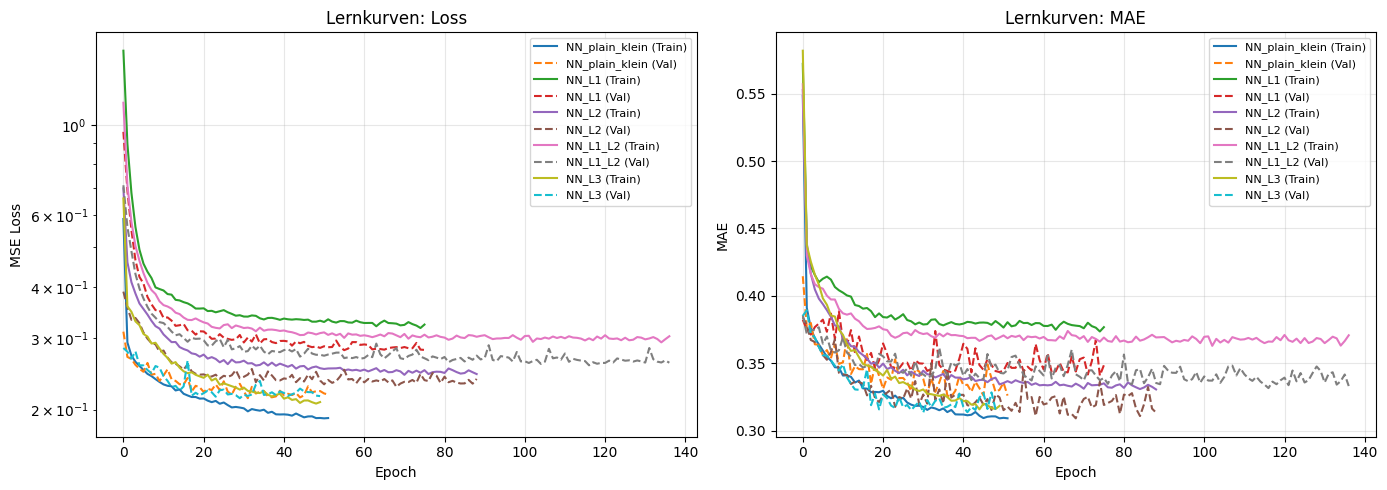

In [14]:
def plot_training_history(histories, names):
    """Lernkurven mehrerer Modelle."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for hist, name in zip(histories, names):
        axes[0].plot(hist.history['loss'], label=f'{name} (Train)')
        axes[0].plot(hist.history['val_loss'], '--', label=f'{name} (Val)')
    
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].set_title('Lernkurven: Loss')
    axes[0].legend(fontsize=8)
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)
    
    for hist, name in zip(histories, names):
        axes[1].plot(hist.history['mae'], label=f'{name} (Train)')
        axes[1].plot(hist.history['val_mae'], '--', label=f'{name} (Val)')
    
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].set_title('Lernkurven: MAE')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    fig.tight_layout()
    save_fig(fig, 'nn_learning_curves')
    return fig

fig = plot_training_history(
    list(histories.values()),
    list(histories.keys())
)

plt.show()

## 7.9 Vergleich NN vs. Lineare Regression

Gespeichert: results/nn_vs_linear_regression.png und results/nn_vs_linear_regression.pdf


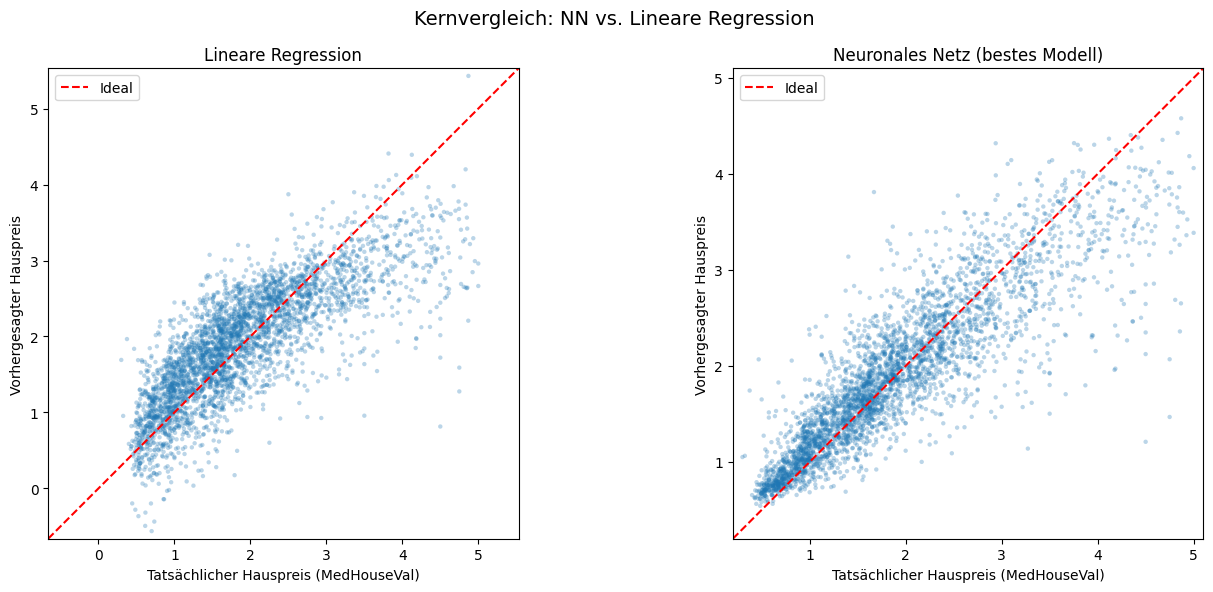

In [16]:
# Bestes NN-Modell vs. Lineare Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_predicted_vs_actual(
    y_test, lr.predict(X_test),
    title="Lineare Regression", ax=axes[0]
)

results_df = pd.DataFrame([result_1, result_2, result_3, result_5])
results_df = results_df.sort_values(by="Test_MSE")
results_df

# bestes NN Modell
best_nn = model_5

y_pred_nn = best_nn.predict(X_test, verbose=0).flatten()

plot_predicted_vs_actual(
    y_test, y_pred_nn,
    title="Neuronales Netz (bestes Modell)", ax=axes[1]
)

fig.suptitle("Kernvergleich: NN vs. Lineare Regression", fontsize=14)
fig.tight_layout()
save_fig(fig, 'nn_vs_linear_regression')
plt.show()

## 7.10 Zusammenfassung

| Aspekt | Lineare Regression | Neuronales Netz |
|--------|-------------------|-----------------|
| R² Test | _eintragen_ | _eintragen_ |
| MAE Test | _eintragen_ | _eintragen_ |
| Trainingszeit | < 1s | _eintragen_ |
| Interpretierbarkeit | Hoch (Koeffizienten) | Gering (Black Box) |
| Hyperparameter | Keine | Architektur, LR, Epochs, ... |

**Fazit:**
- _Hier Ergebnisse und Interpretation eintragen_
- _Wann lohnt sich ein NN gegenüber linearer Regression?_
- _Grenzen und offene Fragen_

Stand 14 März 16:22